# Revisão de código 

Olá! 

Meu nome é Suelen. Estou feliz em revisar seu projeto hoje!

Quando vejo um erro pela primeira vez, apenas aponto. Deixarei você encontrá-lo e corrigi-lo sozinho. Além disso, ao longo do texto, farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Mas se você ainda não consegue lidar com essa tarefa, darei uma dica mais precisa na próxima iteração e também alguns exemplos práticos. Estarei aberto a feedbacks e discussões sobre o tema.

Você pode encontrar meus comentários em caixas verdes, amarelas ou vermelhas como estas:


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Sucesso. Tudo está correto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>

Observações. Algumas recomendações.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário: </b> <a class="tocSkip"></a>

O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.
</div>

Você pode me responder usando isto:

<div class="alert alert-block alert-info">
<b>Resposta do aluno</b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-danger">

<b>Comentário geral v1: </b> <a class="tocSkip"></a>

Parabéns pelo desenvolvimento do projeto, Fabricio! Seu código e suas visualizações estão excelentes! Para prosseguirmos com a aprovação, precisamos dos seguintes ajustes:    
- **Ajustes na seleção do período para a análise dos dados**.    
- **Ajustes no teste de hipótese**   

Adicionei comentários no decorrer do projeto para te auxiliar na resolução.

Estou à disposição para qualquer dúvida. Boa sorte! 🚀
</div>

Muito obrigada pelos ajustes! O projeto está aprovado. 

# Análise de Popularidade de Jogos

Nome: Fabrício Camacho 

Data: 07/09/2024

## Objetivo

O presente projeto tem como objetivo identificar games que possam ter sucesso de vendas a partir de dados abertos para que seja realizada a campanha publicitária da empresa Ice. Dados fornecidos pela empresa serão analisados a seguir e serão utilizados para a tomada de decisão por parte da alta administração.

## Verificação e preparação dos dados

### Importando bibliotecas

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from scipy import stats as st

### Importando os dados para observação

In [21]:
df = pd.read_csv('/datasets/games.csv')

df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [22]:
df.info() # checando informações sobre os dados.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


A partir da observação prévia dos dados, é possível obter as seguites observações necessárias antes de iniciar a análise:
- Os nomes das colunas apresentam maiúsculas e minúsculas. Será necessário manter o padrão snake_case;
- As colunas **Name, Year_of_Release, Genre, Critic_Score, User_Score** e **Rating** apresentam valores ausentes. Será necessário análise minuciosa de cada coluna para preenchimento desses dados;
- A coluna e **User_Score** apresenta tipo de dado que não condiz com a informação proposta: estão apresentados como string. Será necessário mudar para float.

### Convertendo dados

In [23]:
# Alterando nome de colunas para padrão snake_like:
df.columns = df.columns.str.lower()

# Alterando coluna 'user_score' para tipo float:
df['user_score'] = df['user_score'].replace('tbd', np.nan) # Valores contendo 'tbd' são alterados para 'NaN'
df['user_score'] = df['user_score'].astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: float64(7), object(4)
memory usage: 1.4+ MB


### Tratando dados nulos

A seguir vamos descrever como cada coluna contendo dados nulos serão tratadas:
- Na coluna **'name'**: as linhas em que essa coluna encontra-se fazia serão excluidas dos dados, uma vez que não é possível identificar o jogo, o que impede para que qualquer atitude decorrente da análise desses dados seja tomada.
- Na coluna **'year_of_release'**: há jogos que não possuem informação de ano de lançamento. Para preencher esses dados, iremos usar o menor ano de lançamento do mesmo jogo em outras plataformas. Tais informações são encontradas no mesmo banco de dados. As linhas sem informações de ano de lançamento que ainda restarem serão checadas para entender sua relevância perante os dados.

In [24]:
# Removendo linhas que não contém nome de jogo:
df = df.dropna(subset=['name'])

# Tratando jogos sem ano de lançamento:
df['year_of_release'] = df.groupby(['name'])['year_of_release'].transform(lambda x: x.fillna(x.min()))
print(df['year_of_release'].isna().sum())


146


In [25]:
# Retirada de valores nulos restantes da coluna 'year_of_release'.
df = df.dropna(subset=['year_of_release'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16567 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16567 non-null  object 
 1   platform         16567 non-null  object 
 2   year_of_release  16567 non-null  float64
 3   genre            16567 non-null  object 
 4   na_sales         16567 non-null  float64
 5   eu_sales         16567 non-null  float64
 6   jp_sales         16567 non-null  float64
 7   other_sales      16567 non-null  float64
 8   critic_score     8075 non-null   float64
 9   user_score       7540 non-null   float64
 10  rating           9868 non-null   object 
dtypes: float64(7), object(4)
memory usage: 1.5+ MB


Mesmo depois de tentar completar o ano de lançamento dos jogos que não possuem esse dado, ainda restaram 146 jogos sem ano de lançamento. Como esse número de jogos corresponde a um valor baixo perante o universo dos dados, decidimos por eliminar as linhas com tais informações faltantes.

### Conhecendo o valor total em vendas para cada jogo.

Antes de analisarmos os dados, criaremos uma coluna contendo a soma das vendas em todas as regiões para cada jogo. 

In [26]:
# Criando coluna com valor total em vendas por jogo.

df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']


<div class="alert alert-block alert-success">

<b>Comentário: </b> <a class="tocSkip"></a>

Processamento de dados realizado com sucesso

## Análise de dados

Aqui os seguintes pontos serão analisados:
- Verificar quantos jogos foram lançados em anos diferentes e descobrir se há diferença significativa entre eles;
- Verificar como as vendas variaram de plataforma para plataforma, escolhar as plataformas com as maiores vendas totais e construir uma distribuição com base em dados para cada ano;
- Encontrar as plataformas que costumavam ser populares, mas que agora não têm vendas e descobrir quanto tempo leva para as novas plataformas aparecerem e as antigas desaparecerem;
- Determinar para qual período devemos usar os dados e trabalhar apenas com eles, desconsiderando os demais anos;
- Descobrir quais plataformas estão liderando em vendas e quais estão crescendo ou diminuindo, selecionando plataformas potencialmente lucrativas;
- Construir um diagrama de caixa para as vendas globais de todos os jogos, divididos por plataforma, e determinar se as diferenças nas vendas são significativas;
- Verificar como as avaliações de usuários e profissionais afetam as vendas de uma plataforma popular;
- Comparar as vendas em outras plataformas com a plataforma mais popular;
- Verificar se existe alguma diferença em termos de vendas com relação ao gênero dos jogos.

### Entendendo os jogos por ano de lançamento.

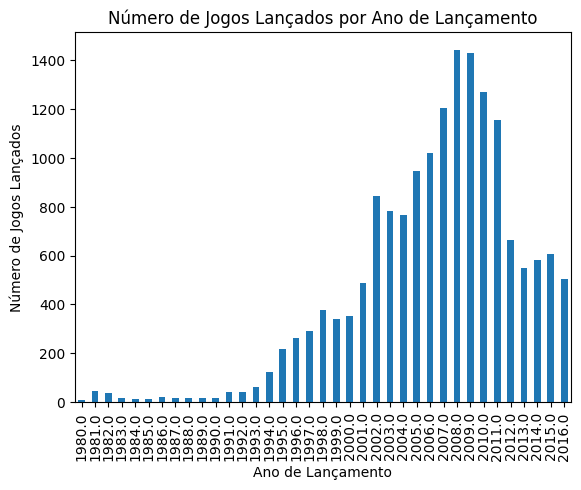

In [27]:
# Contando o número de jogos lançados para cada ano
df_games_per_year = df.groupby(['year_of_release'])['name'].count().reset_index() 
df_games_per_year.rename(columns={'name': 'released_games'}, inplace=True) 

# Criando gráfico de barras para ilustrar número de jogos lançados por ano.
df_games_per_year.plot(x='year_of_release', y='released_games', kind='bar')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Número de Jogos Lançados')
plt.legend('', frameon=False)
plt.title('Número de Jogos Lançados por Ano de Lançamento')
plt.show()


Diante dos dados acima, é importante ressaltar que o número de jogos que não possuem ano registrado não é muito significativo perante o banco de dados geral. Além disso, é possível verificar que mais de 600 jogos foram lançados por ano entre 2002 e 2012, apresentando pico de lançamento em 2008.

### Entendendo os jogos por plataforma

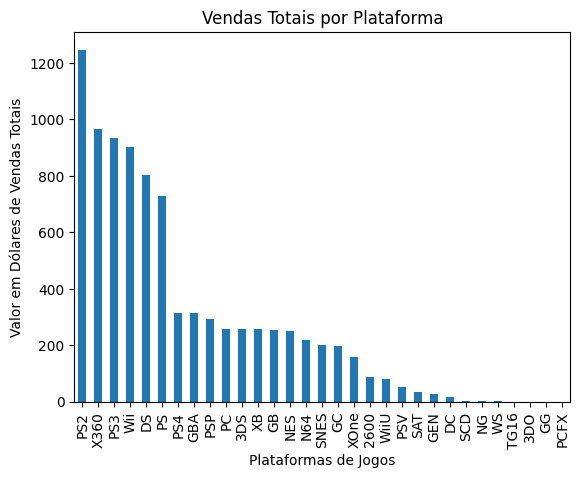

In [28]:
# Criando um df com as vendas totais de cada plataforma e organizando os dados de forma decrescente:
df_sales_per_platform = df.groupby(['platform'])['total_sales'].sum().reset_index()
df_sales_per_platform.sort_values(by='total_sales', ascending=False, inplace=True)
df_sales_per_platform.reset_index(drop=True)

# Criando gráfico de barras com o df criado para entender melhor a diferença de vendas por plataforma.
df_sales_per_platform.plot(x='platform', y='total_sales', kind='bar')
plt.xlabel('Plataformas de Jogos')
plt.ylabel('Valor em Dólares de Vendas Totais')
plt.legend('', frameon=False)
plt.title('Vendas Totais por Plataforma')
plt.show()


É possível verificar através do gráfico que as plataformas são bem divididas em termos de vendas totais. Há um grupo de plataformas que venderam acima de USD 400 milhões em jogos, e um outro grupo de plataformas que venderam menos que esse valor, considerando os anos contidos na base de dados estudada. Dessa maneira, vamos considerar plataformas **PS2, X360, PS3, Wii, DS** e **PS** como sendo as mais populares e analisar suas vendas ano a ano.

### Trabalhando com plataformas populares.

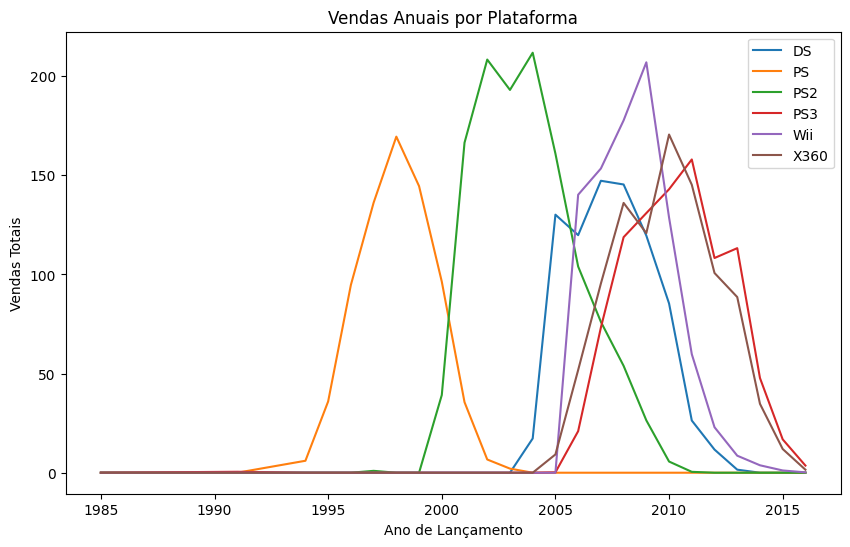

In [29]:
# Filtrando df original somente com as plataformas populares:
popular_platforms = ['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS'] # Plataformas populares
df_popular_platforms = df[df['platform'].isin(popular_platforms)]

# Analisando vendas de plataformas mais populares ano a ano:
df_sales_popplat_per_year = df_popular_platforms.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack().fillna(0)

# Criando um gráfico para entender o comportamento das vendas por ano:
plt.figure(figsize=(10, 6))
for platform in df_sales_popplat_per_year.columns:
    plt.plot(df_sales_popplat_per_year.index, 
             df_sales_popplat_per_year[platform], 
             label=platform)
    
plt.xlabel('Ano de Lançamento')
plt.ylabel('Vendas Totais')
plt.title('Vendas Anuais por Plataforma')
plt.legend()

plt.show()


É possível observar através do gráfico criado acima, que cada plataforma apresenta um pico de vendas em determinado ano e, depois de um tempo, as vendas caem. Agora vamos determinar quanto tempo cada plataforma consegue permanecer com altas vendas. Para isso, vamos considerar que a plataforma deixou de vender quando atingem menos de 1 milhão de dólares em vendas no ano. 

In [30]:
# Filtrando para encontrar as plataformas sem vendas no ultimo ano de 2016:
platforms_without_sales = df_sales_popplat_per_year.columns[df_sales_popplat_per_year.loc[2016] == 0]

print("Plataformas sem vendas atuais (ano de 2016):")
print(platforms_without_sales)

Plataformas sem vendas atuais (ano de 2016):
Index(['DS', 'PS', 'PS2'], dtype='object', name='platform')


In [31]:
# Criando um dicionário para armazenar os DataFrames de cada plataforma contendo somente anos em que houve vendas acima de 1 milhão
df_per_popplat = {}

# Iterando pelas colunas (plataformas)
for platform in df_sales_popplat_per_year.columns:
    
    # Filtrando os anos com vendas maiores que 1 milhão
    years_with_sales = df_sales_popplat_per_year.index[df_sales_popplat_per_year[platform] > 1]
    
    # Criando um novo DataFrame para a plataforma
    df_platform = pd.DataFrame({
        'year_of_release': years_with_sales,
        'sales': df_sales_popplat_per_year.loc[years_with_sales, platform]
    })
    
    # Armazenando o DataFrame no dicionário
    df_per_popplat[platform] = df_platform

# Criando um dicionário para armazenar o tempo de vida de cada plataforma
lifetime_per_popplat = {}

# Iterando pelas chaves do dicionário (plataformas):
for platform, df_platform in df_per_popplat.items():
    
    # Encontrando o primeiro e o último ano de vendas para a plataforma:
    first_year = df_platform['year_of_release'].min()
    last_year = df_platform['year_of_release'].max()
    
    # Calculando a diferença entre os anos
    lifetime = last_year - first_year
    
    # Armazenando o tempo de vida no dicionário
    lifetime_per_popplat[platform] = lifetime
    
# Exibindo o tempo de vida de cada plataforma
print("Tempo de vida de cada plataforma:")
for platform, time in lifetime_per_popplat.items():
    print(f"{platform}: {time} anos")

Tempo de vida de cada plataforma:
DS: 9.0 anos
PS: 9.0 anos
PS2: 10.0 anos
PS3: 10.0 anos
Wii: 9.0 anos
X360: 11.0 anos


Diante dos dados acima, foi possível verificar que, de todas as plataformas populares, **DS, PS** e **PS2** são plataformas que não apresentam mais vendas agora em 2016. Somente as plataformas **X360** e **PS3** ainda apresentam vendas atualmente. Além disso, ao analisar o tempo que cada plataforma popular apresenta vendas altas, é possível observar que cada plataforma tem uma durabilidade de popularidade entre 9 e 11 anos. Diante de tal dado, para definirmos quais jogos e plataformas terão vendas significativas em 2017, utilizaremos jogos e plataformas que tiveram seu lançamento a partir de 2015 até então e verificar como as vendas de cada plataforma então se comportando desde então.

In [32]:
# Filtrando dados de jogos lançados a partir de 2014:
df_recent_games = df[df['year_of_release'] > 2013]

# Conhecendo plataformas que apresentam vendas em 2016:
df_2016_games = df_recent_games[df_recent_games['year_of_release'] == 2016]
df_2016_platform_sales = df_2016_games.groupby('platform')['total_sales'].sum().reset_index()

# Ranqueando as plataformas com vendas em 2016 em ordem decrescente de vendas:
df_2016_platform_sales.sort_values(by='total_sales', ascending=False, inplace=True)
df_2016_platform_sales.reset_index(drop=True)


,platform,total_sales
0,PS4,69.25
1,XOne,26.15
2,3DS,15.14
3,PC,5.25
4,WiiU,4.60
5,PSV,4.25
6,PS3,3.60
7,X360,1.52
8,Wii,0.18


<div class="alert alert-block alert-danger">

<b>Comentário: </b> <a class="tocSkip"></a>

São necessários ajustes na escolha do período temporal. É raro utilizar dados de mais de 2-3 anos para prever as vendas do próximo ano, mesmo em negócios tradicionais. Na indústria dinâmica de jogos de computador, evitar períodos mais longos é ainda mais importante, pois você pode acabar rastreando tendências obsoletas. No entanto, também não é aconselhável usar um período muito curto. **O ideal seria usar um intervalo de 2-3 anos, como 2014-2016, 2015-2016 ou 2013-2016.** 

</div>

<div class="alert alert-block alert-info">
<b>Resposta do aluno</b> <a class="tocSkip"></a>
    
Resolvi analisar os dados dos últimos três anos então (2014 a 2016). Obrigado pela dica.
    
</div>

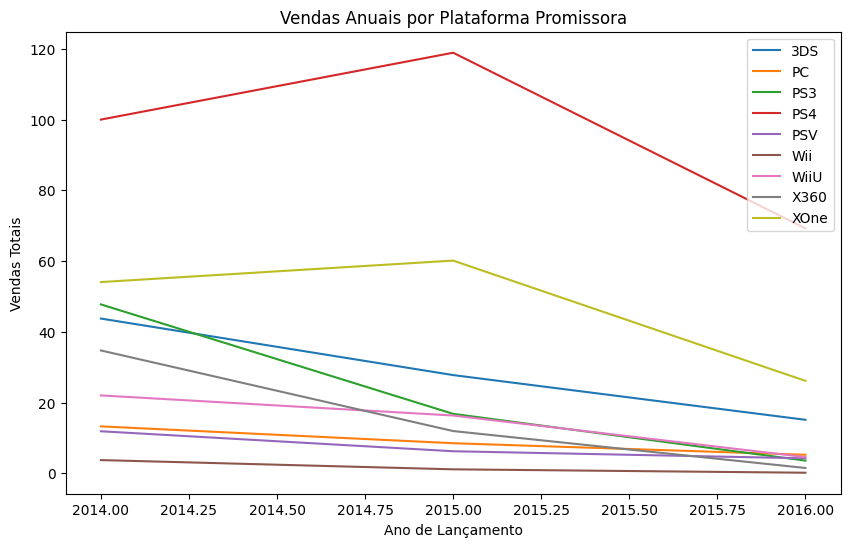

In [33]:
# Filtrando dados dos últimos anos usando somente as plataformas promissoras, que apresentam vendas em 2016:
promising_platforms = ['PS4', 'XOne', '3DS', 'PC', 'WiiU', 'PSV', 'PS3', 'X360', 'Wii'] # Plataformas populares
df_promising_platforms = df_recent_games[df_recent_games['platform'].isin(promising_platforms)]

# Entendendo como estão as vendas por plataformas promissoras a partir de 2014
df_promising_platforms_sales = df_promising_platforms.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack().fillna(0)

# Criando gráfico para entender vendas de plataformas promissoras:
plt.figure(figsize=(10, 6))
for platform in df_promising_platforms_sales.columns:
    plt.plot(df_promising_platforms_sales.index, 
             df_promising_platforms_sales[platform], 
             label=platform)
    
plt.xlabel('Ano de Lançamento')
plt.ylabel('Vendas Totais')
plt.title('Vendas Anuais por Plataforma Promissora')
plt.legend()

plt.show()

Diante do gráfico acima é possivel verificar que todas as plataformas veem apresentando queda nas vendas. Porém as plataformas **Wii, X360** e **PS3** apresentaram pico de vendas nos anos anteriores e atualmente já atingiram tempo de vida igual ou superior a 9 anos. Por esse motivo, tais plataformas tendem a diminuir vendas cada vez mais e não são consideradas promissoras.
Entretanto, as plataformas **PS4, XOne** e **3DS** já apresentaram vendas superiores a 50 milhões de dolares por ano e surgiram há pelo menos 6 anos. Considerando um tempo de vida de pelo menos 9 anos, tais plataformas podem ser consideradas promissoras.
As plataformas **WiiU, PC** e **PSV** ainda não apresentaram vendas superiores a 50 milhões de dólares por ano e, mesmo assim, apresentam queda nas vendas em 2016. Tais fatos podem mostrar que essas plataformas podem não apresentar vendas significativas a partir de 2017.


### Verificando se há diferença significativa nas vendas entre plataformas.
Vamos verificar se as vendas entre as plataformas apresentam alguma diferença significativa, considerando somente as vendas dos últimos 9 anos.

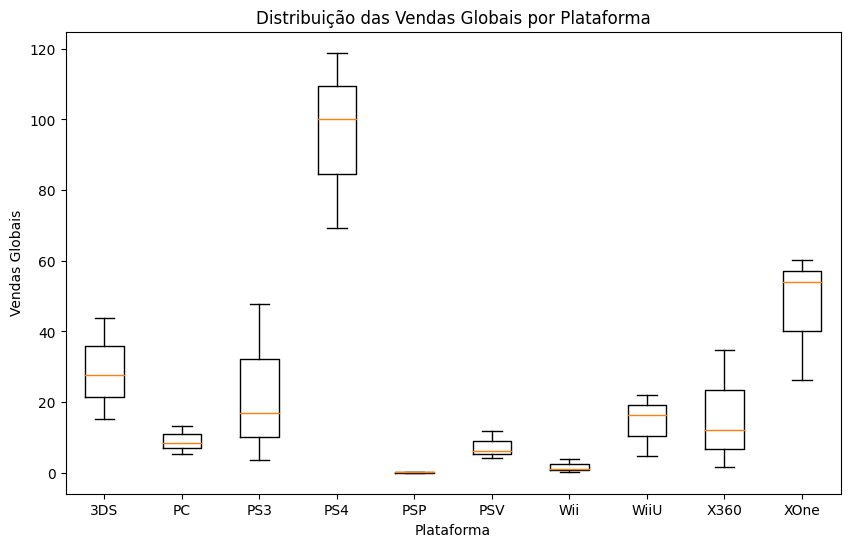

In [34]:
# Criando dataframe considerando vendas por plataforma por ano usando as plataformas com vendas a partir de 2014:
df_sales_per_platform_year = df_recent_games.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack().fillna(0)

# Criando diagrama de caixa
plt.figure(figsize=(10, 6))
plt.boxplot(df_sales_per_platform_year.values, 
            labels=df_sales_per_platform_year.columns)
plt.xlabel('Plataforma')
plt.ylabel('Vendas Globais')
plt.title('Distribuição das Vendas Globais por Plataforma')

plt.show()


É importante notar que, de acordo com o diagrama de caixa acima, as dispersões de vendas da maioria das plataformas se sobrepõem, indicando assim que não há diferença significativa entre elas. Porém, as vendas da plataforma **PS4** apresentam destaque e tem diferença significativa das demais plataformas. Isso nos indica que as vendas da maioria das plataformas se comportam de maneira muito semelhante e que somente a plataforma **PS4** que apresente venda significativamente mais alta.

### Entendendo influência de avaliações de usuários e críticos nas vendas
Agora vamos verificar se a avaliação dos usuários e dos críticos tem relação com as vendas dos jogos. Essa informação é importante para verificarmos se tais notas devem ser levadas em consideração para definirmos se jogos terão popularidade ou não. Para isso, vamos selecionar a plataforma popular **PS2** e estudar a influência das avaliações de usuários e críticos nas vendas dos jogos. 

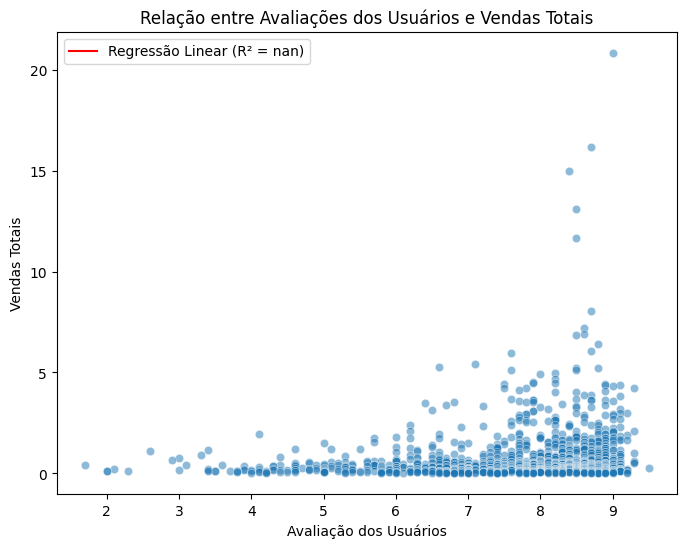

In [35]:
# Criando df somente com dados da plataforma PS2
df_ps2 = df[df['platform'] == 'PS2']

# Criando gráfico de dispersão comparando vendas totais e avaliação de usuários para PS2
plt.figure(figsize=(8, 6))
sns.scatterplot(x='user_score', 
                y='total_sales',
                data=df_ps2,
                alpha=0.5)

# Calculando a reta da regressão linear
slope, intercept, r_value, p_value, std_err = linregress(df_ps2['user_score'], df_ps2['total_sales'])
x_vals = np.linspace(df_ps2['user_score'].min(), df_ps2['user_score'].max(), 100)
y_vals = slope * x_vals + intercept
plt.plot(x_vals, y_vals, color='red', label=f'Regressão Linear (R² = {r_value**2:.2f})')

plt.xlabel('Avaliação dos Usuários')
plt.ylabel('Vendas Totais')
plt.title('Relação entre Avaliações dos Usuários e Vendas Totais')
plt.legend()

plt.show()


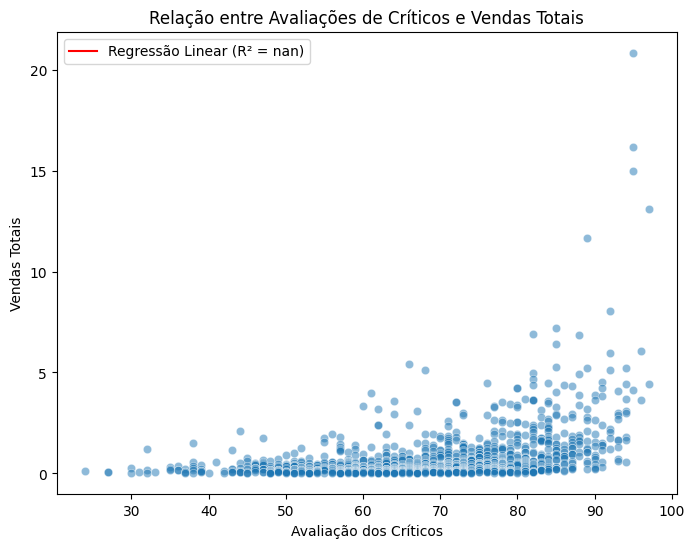

In [36]:
# Criando gráfico de dispersão comparando vendas totais e avaliação de críticos para PS2
plt.figure(figsize=(8, 6))
sns.scatterplot(x='critic_score', 
                y='total_sales',
                data=df_ps2,
                alpha=0.5)

# Calculando a reta da regressão linear
slope, intercept, r_value, p_value, std_err = linregress(df_ps2['critic_score'], df_ps2['total_sales'])
x_vals = np.linspace(df_ps2['critic_score'].min(), df_ps2['critic_score'].max(), 100)
y_vals = slope * x_vals + intercept
plt.plot(x_vals, y_vals, color='red', label=f'Regressão Linear (R² = {r_value**2:.2f})')

plt.xlabel('Avaliação dos Críticos')
plt.ylabel('Vendas Totais')
plt.title('Relação entre Avaliações de Críticos e Vendas Totais')
plt.legend()

plt.show()

In [37]:
# Calculando correlação entre avaliação de usuários e vendas totais para PS2
user_score_correlation = df_ps2['total_sales'].corr(df_ps2['user_score'])

#Exibindo o valor da correlação
print(f"Correlação entre vendas totais e avaliação de usuários: {user_score_correlation:.2f}")


Correlação entre vendas totais e avaliação de usuários: 0.17


In [38]:
# Calculando correlação entre avaliação de críticos e vendas totais para PS2
critic_score_correlation = df_ps2['total_sales'].corr(df_ps2['critic_score'])

#Exibindo o valor da correlação
print(f"Correlação entre vendas totais e avaliação de críticos: {critic_score_correlation:.2f}")


Correlação entre vendas totais e avaliação de críticos: 0.40


Diante dos resultados acima dispostos, tanto as notas dos usuários quanto as notas dos críticos não apresentam correlação com o valor em vendas. Dessa maneira, tais notas não podem ser consideradas como referência ao definir se um jogo terá altas vendas ou não.

### Entendendo vendas de jogos por gênero.
Agora vamos verificar se existe alguma relação entre jogos lucrativos e gênero dos mesmos. Para isso, vamos analisar o dataframe criado com os jogos lançados mais recentemente.

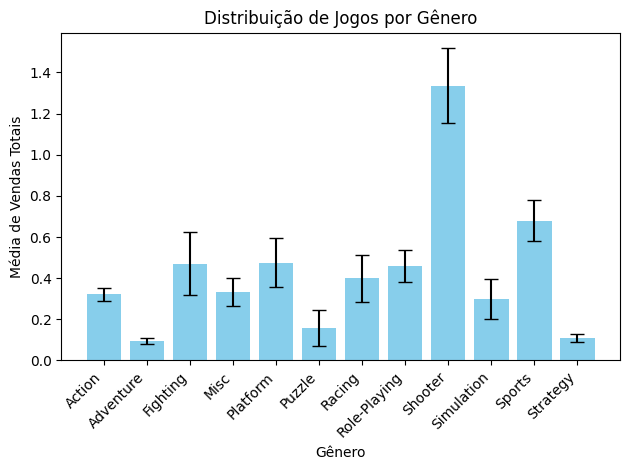

In [39]:
# Agrupando jogos e calculando média e erro padrão de vendas por gênero
genre_stats = df_recent_games.groupby('genre')['total_sales'].agg(['mean', 'sem'])

# Criando gráfico de barras
plt.bar(genre_stats.index, genre_stats['mean'], yerr=genre_stats['sem'], capsize=5, color='skyblue')
plt.xlabel('Gênero')
plt.ylabel('Média de Vendas Totais')
plt.title('Distribuição de Jogos por Gênero')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


Considerando as médias das vendas totais e o erro padrão das mesmas para os jogos lançados a partir de 2014, os jogos dos gêneros **Shooter** apresentam maior média de vendas. Já os jogos dos gêneros **Adventure, Puzzle** e **Strategy** apresentam baixo volume de vendas significativo, quando comparados aos demais gêneros. Os demais gênero de jogos não devem apresentar diferença significativa de vendas entre si, mas apresentam volume de vendas intermediário, quando comparados ao gênero **Shooter** (maior em vendas) e **Adventure, Puzzle** e **Strategy** (menor em vendas).

## Criando perfil de usuários por região
Iremos analisar cada região e definirmos um perfil de usuário para cada uma delas. Definiremos os seguintes pontos para cada região:
- Quais são as cinco plataformas mais relevantes em termos de vendas;
- Quais são os cinco gêneros mais relevantes em termos de vendas;
- Verificar se a classificação ESRB afetam as vendas.

Importante lembrar que essas definições serão realizadas com dados de jogos lançados a partir de 2007.

### América do Norte
#### Verificando plataformas mais populares

In [40]:
# Agrupando vendas na América do Norte por plataforma
df_recent_na_sales = df_recent_games.groupby('platform')['na_sales'].sum().reset_index()

# Ranqueando plataformas por valor de vendas
df_recent_na_sales.sort_values(by='na_sales', ascending=False, inplace=True)
df_recent_na_sales.reset_index(drop=True, inplace=True)

# Imprimindo resultado
print("As cinco plataformas que mais venderam na América do Norte são:")
print(df_recent_na_sales['platform'].head(5))


As cinco plataformas que mais venderam na América do Norte são:
0     PS4
1    XOne
2    X360
3     3DS
4     PS3
Name: platform, dtype: object


#### Verificando gêneros mais populares

In [41]:
# Agrupando vendas na América do Norte por gênero de jogo
df_relevant_genre_na = df_recent_games.groupby('genre')['na_sales'].sum().reset_index()

# Ranqueando gênero de jogo por valor de vendas
df_relevant_genre_na.sort_values(by='na_sales', ascending=False, inplace=True)
df_relevant_genre_na.reset_index(drop=True, inplace=True)

# Imprimindo resultado
print("Os cinco gêneros de jogos mais vendidos na América do Norte são:")
print(df_relevant_genre_na['genre'].head(5))


Os cinco gêneros de jogos mais vendidos na América do Norte são:
0         Shooter
1          Action
2          Sports
3    Role-Playing
4            Misc
Name: genre, dtype: object


#### Checando classificação ESRB e vendas

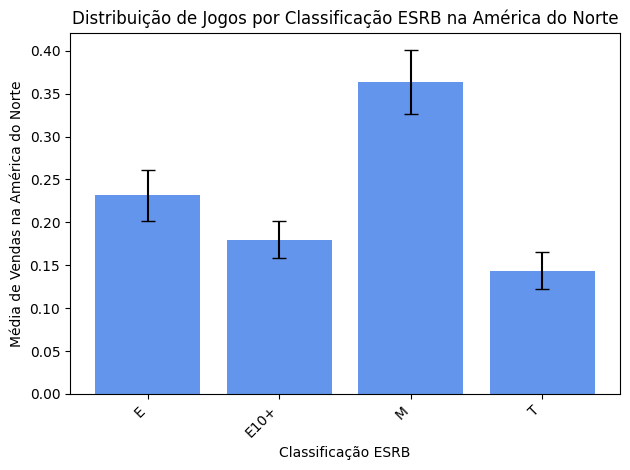

In [42]:
# Calculando média e erro padrão de vendas por classificação ESRB na América do Norte
genre_stats_na = df_recent_games.groupby('rating')['na_sales'].agg(['mean', 'sem'])

# Criando gráfico de barras
plt.bar(genre_stats_na.index, genre_stats_na['mean'], yerr=genre_stats_na['sem'], capsize=5, color='cornflowerblue')
plt.xlabel('Classificação ESRB')
plt.ylabel('Média de Vendas na América do Norte')
plt.title('Distribuição de Jogos por Classificação ESRB na América do Norte')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Na América do Norte, os jogos com classificação ESRB **M** apresetam média de vendas significativamente maior que as demais classificações. A classificação M é caracterizada por jogos indicados para maiores de 17 anos de idade.

As demais classificações apresentadas (E, E10+, e T) apresentam média de vendas muito semelhantes entre si.

### Europa
#### Verificando plataformas mais populares

In [43]:
# Agrupando vendas na Europa por plataforma
df_recent_eu_sales = df_recent_games.groupby('platform')['eu_sales'].sum().reset_index()

# Ranqueando plataformas por valor de vendas
df_recent_eu_sales.sort_values(by='eu_sales', ascending=False, inplace=True)
df_recent_eu_sales.reset_index(drop=True, inplace=True)

# Imprimindo resultado
print("As cinco plataformas que mais venderam na Europa são:")
print(df_recent_eu_sales['platform'].head(5))

As cinco plataformas que mais venderam na Europa são:
0     PS4
1    XOne
2     PS3
3      PC
4     3DS
Name: platform, dtype: object


#### Verificando gêneros mais populares

In [45]:
# Agrupando vendas na Europa por gênero de jogo
df_relevant_genre_eu = df_recent_games.groupby('genre')['eu_sales'].sum().reset_index()

# Ranqueando gênero de jogo por valor de vendas
df_relevant_genre_eu.sort_values(by='eu_sales', ascending=False, inplace=True)
df_relevant_genre_eu.reset_index(drop=True, inplace=True)

# Imprimindo resultado
print("Os cinco gêneros de jogos mais vendidos na Europa são:")
print(df_relevant_genre_eu['genre'].head(5))

Os cinco gêneros de jogos mais vendidos na Europa são:
0          Action
1         Shooter
2          Sports
3    Role-Playing
4          Racing
Name: genre, dtype: object


#### Checando classificação ESRB e vendas

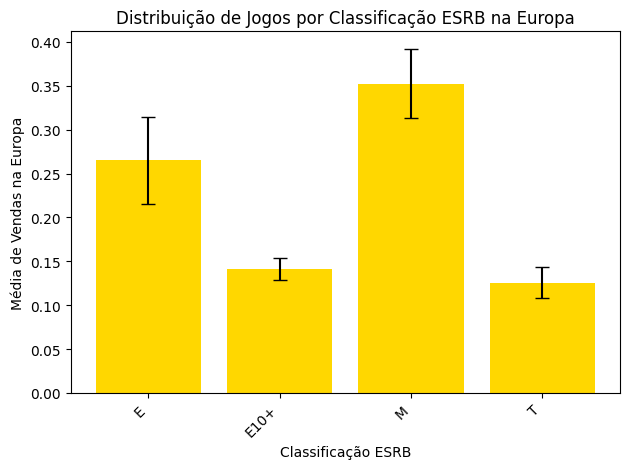

In [46]:
# Calculando média e erro padrão de vendas por classificação ESRB na Europa
genre_stats_eu = df_recent_games.groupby('rating')['eu_sales'].agg(['mean', 'sem'])

# Criando gráfico de barras
plt.bar(genre_stats_eu.index, genre_stats_eu['mean'], yerr=genre_stats_eu['sem'], capsize=5, color='gold')
plt.xlabel('Classificação ESRB')
plt.ylabel('Média de Vendas na Europa')
plt.title('Distribuição de Jogos por Classificação ESRB na Europa')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Na Europa, os jogos que apresentam classificação ESRB **M** e **E** apresetam média de vendas significativamente maior que as demais classificações. A classificação M é caracterizada por jogos indicados para maiores de 17 anos de idade, já a classificação E é caracterizada por jogos indicados para todas as idades.

As demais classificações apresentadas (E10+ e T) apresentam média de vendas muito semelhantes entre si.

### Japão
#### Verificando plataformas mais populares

In [47]:
# Agrupando vendas na Japão por plataforma
df_recent_jp_sales = df_recent_games.groupby('platform')['jp_sales'].sum().reset_index()

# Ranqueando plataformas por valor de vendas
df_recent_jp_sales.sort_values(by='jp_sales', ascending=False, inplace=True)
df_recent_jp_sales.reset_index(drop=True, inplace=True)

# Imprimindo resultado
print("As cinco plataformas que mais venderam na Japão são:")
print(df_recent_jp_sales['platform'].head(5))

As cinco plataformas que mais venderam na Japão são:
0     3DS
1     PS4
2     PSV
3     PS3
4    WiiU
Name: platform, dtype: object


#### Verificando gêneros mais populares

In [48]:
# Agrupando vendas na Japão por gênero de jogo
df_relevant_genre_jp = df_recent_games.groupby('genre')['jp_sales'].sum().reset_index()

# Ranqueando gênero de jogo por valor de vendas
df_relevant_genre_jp.sort_values(by='jp_sales', ascending=False, inplace=True)
df_relevant_genre_jp.reset_index(drop=True, inplace=True)

# Imprimindo resultado
print("Os cinco gêneros de jogos mais vendidos na Japão são:")
print(df_relevant_genre_jp['genre'].head(5))

Os cinco gêneros de jogos mais vendidos na Japão são:
0    Role-Playing
1          Action
2        Fighting
3            Misc
4         Shooter
Name: genre, dtype: object


#### Checando classificação ESRB e vendas

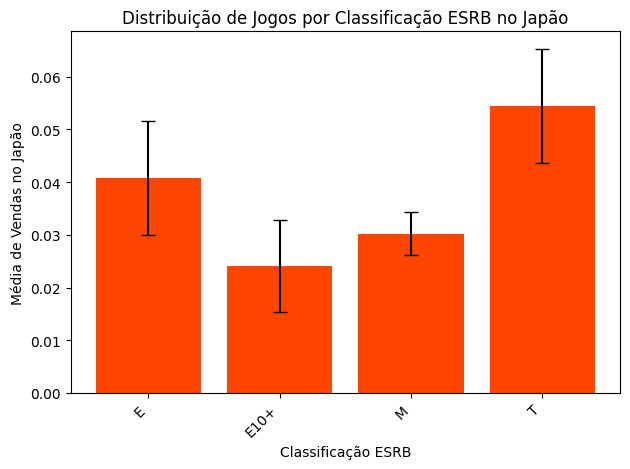

In [49]:
# Calculando média e erro padrão de vendas por classificação ESRB no Japão
genre_stats_jp = df_recent_games.groupby('rating')['jp_sales'].agg(['mean', 'sem'])

# Criando gráfico de barras
plt.bar(genre_stats_jp.index, genre_stats_jp['mean'], yerr=genre_stats_jp['sem'], capsize=5, color='orangered')
plt.xlabel('Classificação ESRB')
plt.ylabel('Média de Vendas no Japão')
plt.title('Distribuição de Jogos por Classificação ESRB no Japão')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

No Japão, os jogos que apresentam classificação ESRB **T** apresetam média de vendas significativamente maior que os jogos classificados como E10+ e M, porém apresenta média de vendas semelhante aos jogos com classificação **E**. No entanto, as médias de vendas dos jogos classificados como **E, E10+** e **M** são significativamente semelhantes.

## Gerando e testando hipóteses
### Notas de usuários para XOne e PC
Vamos verificar se há diferença significativa entre as médias de notas de usuários para XOne e PC. Para isso faremos um test-t e testaremos as seguintes hipóteses:

- H0: As médias das notas dos usuários de XOne e PC são iguais.
- H1: As médias das notas dos usuários de XOne e PC são diferentes.

Os valores ausentes para notas de usuário serão retiradas das amostras, uma vez que estima-las poderá gerar erro e interferir no resultado estatístico.

In [73]:
# Filtrando as notas de usuário de XOne e PC e desconsiderando valores ausentes
xone_scores = df_recent_games[df_recent_games['platform'] == 'XOne']['user_score'].dropna()
pc_scores = df_recent_games[df_recent_games['platform'] == 'PC']['user_score'].dropna()

# Realizando Test t
result = st.ttest_ind(xone_scores, pc_scores)

# Verificando resultado
alpha = 0.05

print('valor_p: ', result.pvalue)

if result.pvalue < alpha:
    print("As médias das notas dos usuários de XOne e PC são diferentes.")
else:
    print("As médias das notas dos usuários de XOne e PC são iguais.")


valor_p:  0.10450507919348415
As médias das notas dos usuários de XOne e PC são iguais.


### Notas de usuários para gêneros Action e Sports
Vamos verificar se há diferença significativa entre as médias de notas de usuários para gêneros Action e Sports. Para isso faremos um test-t e testaremos as seguintes hipóteses:
- H0: As médias das notas dos usuários para os gêneros Action e Sports são iguais.
- H1: As médias das notas dos usuários para os gêneros Action e Sports são diferentes.

Os valores ausentes para notas de usuário serão retiradas das amostras, uma vez que estima-las poderá gerar erro e interferir no resultado estatístico.

In [75]:
# Filtrando as notas de usuário para os gêneros de Action e Sports e desconsiderando valores ausentes
action_scores = df_recent_games[df_recent_games['genre'] == 'Action']['user_score'].dropna()
sports_scores = df_recent_games[df_recent_games['genre'] == 'Sports']['user_score'].dropna()

# Realizando Test t
result = st.ttest_ind(action_scores, sports_scores)

# Verificando resultado
alpha = 0.05

print('valor_p: ', result.pvalue)

if result.pvalue < alpha:
    print("As médias das notas dos usuários para os gêneros Action e Sports são diferentes.")
else:
    print("As médias das notas dos usuários para os gêneros Action e Sports são iguais.")


valor_p:  2.8711147985105864e-19
As médias das notas dos usuários para os gêneros Action e Sports são diferentes.


<div class="alert alert-block alert-danger">

<b>Comentário: </b> <a class="tocSkip"></a>

Os testes de hipótese acima requerem ajustes pois o resultado do valor_p está "nan". 
**Esse valor no resultado do teste t geralmente ocorre quando há valores ausentes ou inválidos nos seus dados.** Por exemplo, se action_scores ou sports_scores contiver valores NaN, a função scipy.stats.ttest_ind pode não lidar corretamente com eles. Isso pode levar a um resultado NaN para a estatística do teste t ou para o valor-p.
</div>


<div class="alert alert-block alert-info">
<b>Resposta do aluno</b> <a class="tocSkip"></a>
    
Retirei os valores ausentes e expliquei a retirada em texto.
    
</div>

In [33]:
#Código gerado pela revisora 
sports_scores

3        8.0
13       7.7
15       7.4
77       4.3
86       NaN
        ... 
16655    NaN
16656    NaN
16676    NaN
16688    NaN
16700    NaN
Name: user_score, Length: 1132, dtype: float64

In [32]:
#Código gerado pela revisora 
action_scores

16       8.2
23       8.1
42       8.3
46       NaN
51       7.9
        ... 
16680    NaN
16691    NaN
16692    7.6
16699    NaN
16710    NaN
Name: user_score, Length: 2223, dtype: float64

## Conclusões
De acordo com a análise dos dados realizada, as seguintes conclusões podem ser tiradas:
- Plataformas consideradas populares apresentam altas vendas num período de 9 anos;
- As plataformas **PS4, XOne, 3DS, PC, WiiU** e **PSV** tem maior probabilidade de apresentar vendas altas em 2017 por apresentarem altas vendas e ainda estarem no período de ciclo de vida de 9 anos;
- Notas de críticos e de usuário não apresentam relação com sucesso em vendas;
- De maneira geral, o gênero **Shooter** é o que apresentou maior volume de vendas, porém outros gêneros também apresentam vendas relevantes;
- De maneira geral, os gêneros **Adventure** e **Strategy** são os que apresentaram menor volume de vendas;
- Considerando regiões específicas:
    - Na América do Norte, as plataformas **PS4, XOne, X360, 3DS** e **PS3**, bem como os jogos do gênero **Shooter, Action, Sports, Misc** e **Role-Playing** apresentam maior volume de vendas. Além disso, jogos com classificação ESRB **M** são aqueles que mais vendem;
    - Na Europa, as plataformas **PS4, XOne, PS3, PC** e **3DS**, bem como os jogos do gênero **Action, Shooter, Sports, Role-Playing** e **Racing** apresentam maior volume de vendas. Além disso, jogos com classificação ESRB **M** e **E** são aqueles que mais vendem;
    - Na Japão, as plataformas **3DS, PS4, PSV, PS3** e **WiiU**, bem como os jogos do gênero **Role-Playing, Action, Fighting, Misc** e **Shooter** apresentam maior volume de vendas. Além disso, jogos com classificação ESRB **T** e **E** são aqueles que mais vendem;
- Não há diferença entre as notas de usuário entre XOne e PC;
- Há diferença significativa entre as notas de usuário para os gêneros Action e Sports, sendo as notas para o gênero Sports maiores que aquelas para o gênero Action.